# MA124 Maths By Computer: Assignment 2

Student number: 2012113

# B. The pendulum with damping 

A model for a damped pendulum is 

$$
\ddot \theta = - \sin \theta - \mu \dot \theta
$$

where $\theta$ is the angle of the pendulum from the downward vertical (negative $y$ direction) and $\mu$ is a parameter governing the strength of the damping. For $\mu > 0$, all solutions (except for those with the pendulum exactly inverted), come to rest with the pendulum at $\theta=0 \text{ mod } 2\pi$.

Letting $v$ denote the angular velocity of the pendulum, $ v = \dot \theta$ 
so the above second-order ODE is equivalent to the system of first-order ODEs
$$ v = \dot \theta$$
$$\dot v = - \mu v - \sin\theta$$

The Python code cells below compute numerical solutions to the pendulum equations by calling the SciPy ODE solver odeint.  Solutions are found for three different initial conditions. Plots show the evolution of $\theta$ and $v$ for each case. A forth plot shows a $(\theta, v)$ phase plane in which all three trajectories are plotted. Starting and endpoints are marked in the plot.

For a fixed value of $\mu=0.05$, initial conditions are chosen such that: pendulum comes at rest at $\theta = 0$, at $\theta > 0$ and $\theta <0$.

- $\theta_0=\pi/2$, $v_0=0$, starting horizontally with zero velocity. As time passes velocity decreases and the amplitude decreases until the pendulum comes at rest vertically at $\theta=0$.
    
- $\theta_0 = -\pi/2$,  $v_0=1.75$, starting horizontally with positive velocity. The pendulum starts horizontal in the left and turns anticlockwise. It has enough velocity to make one full turn and then comes at rest at $\theta=2\pi$.

- $\theta_0 = \pi-0.1$,  $v_0=-1.25$, starting very near the top to the right. The pendulum is almost vertically and turns clockwise. The velocity favours the starting movement and has enough velocity to make two full turns and then comes at rest at $\theta=-4\pi$. 

The fourth figure plots the phase portrait ($\theta$,$v$) with the three trajectories. In addition, two extra trajectories are plotted. One of the trajectories, is for a pendulum with different $\mu$. If we look at pendulum 3 and pendulum 5, we can see that both have the same initial conditions $\theta = \pi-0.1$ and $v=-1.5$ but one is from the pendulum with $\mu=0.05$ (green) and the other from a pendulum with $\mu=0.1$ (red). One can check that with the same initial conditions, the pendulum with $\mu=0.05$ does two full turns whereas the pendulum with higher $\mu=0.1$ only does one full turn, because the damping coefficient is higher in the latter. A star shows the initial points and a diamond the final points, which are at  $\theta=0 \text{ mod } 2\pi$ and $v=0$. The other extra plot (purple) has $\theta = 5\pi/6$, $ v=1.25$ and comes at rest at $\theta=4\pi$.

In [1]:
# import libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [2]:
# --- First define the RHS of ODE system --- #
mu = 0.05
def Pendulum(y, t):
    
    theta, vel = y
    
    theta_dot = vel
    vel_dot = - np.sin(theta)-mu*vel
    
    return theta_dot, vel_dot

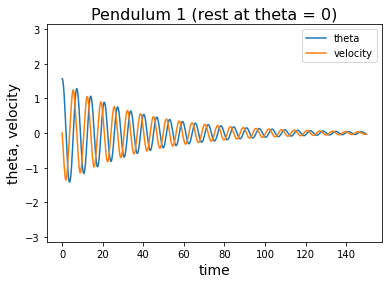

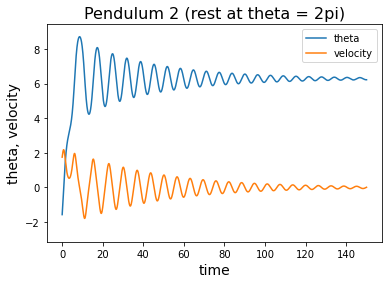

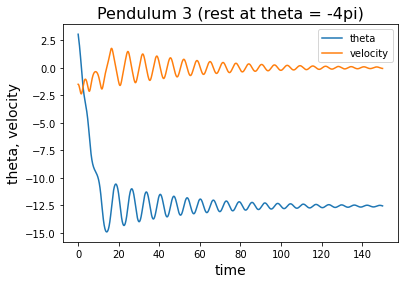

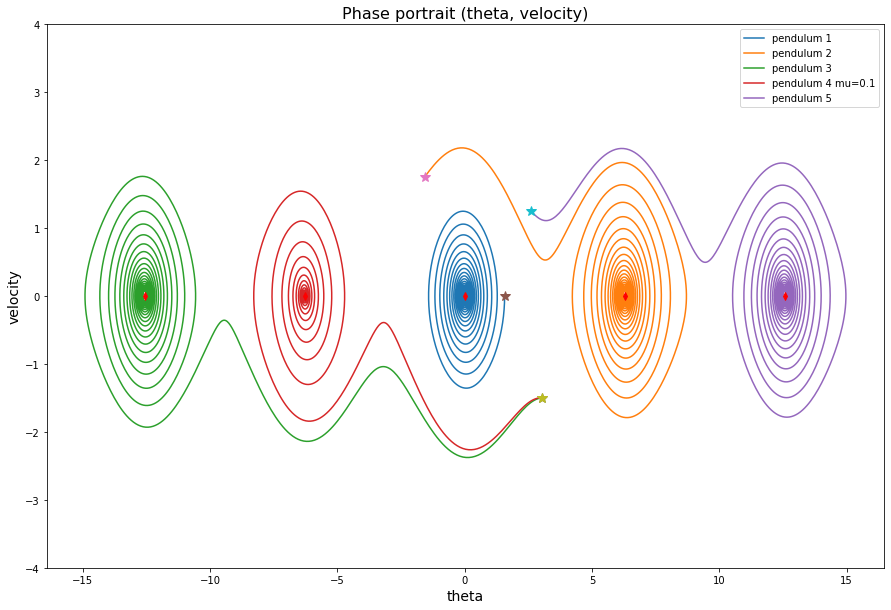

In [3]:
# --- Problem setup --- #

tf = 150
Nsteps = 3000
t = np.linspace(0, tf, Nsteps+1)

# --- Call the ODE solver and extract solutions for three different intitial conditions --- #

y_sol_1 = odeint(Pendulum, [np.pi/2, 0], t)
y_sol_2 = odeint(Pendulum, [-np.pi/2, 1.75], t)
y_sol_3 = odeint(Pendulum, [np.pi-0.1, -1.5], t)

# extract theta and vel from y
theta_1 = y_sol_1[:,0]
vel_1 = y_sol_1[:,1]
theta_2 = y_sol_2[:,0]
vel_2 = y_sol_2[:,1]
theta_3 = y_sol_3[:,0]
vel_3 = y_sol_3[:,1]

# --- Plot various interesting things --- #

# plot numerical solution 1
plt.plot(t, theta_1, label="theta")
plt.plot(t, vel_1, label="velocity")

# labels etc
plt.ylim(-np.pi, np.pi)
plt.xlabel("time", fontsize=14)
plt.ylabel("theta, velocity", fontsize=14)
plt.title("Pendulum 1 (rest at theta = 0)", fontsize=16)
plt.legend()
plt.show()        

# plot the numerical solution 2
plt.plot(t, theta_2, label="theta")
plt.plot(t, vel_2, label="velocity")

# labels etc
plt.ylim(-np.pi, 3*np.pi)
plt.xlabel("time", fontsize=14)
plt.ylabel("theta, velocity", fontsize=14)
plt.title("Pendulum 2 (rest at theta = 2pi)", fontsize=16)
plt.legend()
plt.show()        

# plot the numerical solution 3
plt.plot(t, theta_3, label="theta")
plt.plot(t, vel_3, label="velocity")

# labels etc
plt.xlabel("time", fontsize=14)
plt.ylabel("theta, velocity", fontsize=14)
plt.title("Pendulum 3 (rest at theta = -4pi)", fontsize=16)
plt.legend()
plt.show()        



# Extra pendulum with a different mu
mu_1 = 0.1
def Pendulum1(y, t):
    
    theta, vel = y
    
    theta_dot = vel
    vel_dot = - np.sin(theta)-mu_1*vel
    
    return theta_dot, vel_dot

# --- Call the ODE solver and extract solutions  --- #

y_sol_4 = odeint(Pendulum1, [np.pi-0.1, -1.5], t)   
y_sol_5 = odeint(Pendulum, [5*np.pi/6, 1.25], t)

# extract theta and vel from y
theta_4 = y_sol_4[:,0]
vel_4 = y_sol_4[:,1]
theta_5 = y_sol_5[:,0]
vel_5 = y_sol_5[:,1]


# --- Plot Phase Portrait --- #

fig = plt.figure(figsize=(15,10))
plt.plot(theta_1,vel_1,label="pendulum 1")
plt.plot(theta_2,vel_2,label="pendulum 2")
plt.plot(theta_3,vel_3,label="pendulum 3")
plt.plot(theta_4,vel_4,label="pendulum 4 mu=0.1")
plt.plot(theta_5,vel_5,label="pendulum 5")
plt.ylim(-4,4)

# labels phase portrait
plt.xlabel("theta",fontsize=14)
plt.ylabel("velocity",fontsize=14)
plt.title("Phase portrait (theta, velocity)", fontsize=16)
plt.legend()

# put some markers to show initial and final states
plt.plot(theta_1[0], vel_1[0], '*', markersize = 10)
plt.plot(0, 0, 'rd', markersize = 5)
plt.plot(theta_2[0], vel_2[0], '*', markersize = 10)
plt.plot(2*np.pi,0, 'rd', markersize = 5)
plt.plot(theta_3[0], vel_3[0], '*', markersize = 10)
plt.plot(-2*np.pi, 0, 'rd', markersize = 5)
plt.plot(theta_4[0], vel_4[0], '*', markersize = 10)
plt.plot(-4*np.pi,0, 'rd', markersize = 5)
plt.plot(theta_5[0], vel_5[0], '*', markersize = 10)
plt.plot(4*np.pi,0, 'rd', markersize = 5)

plt.show()


